In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
import numpy as np

In [2]:
file = "dvi_dim.csv"

In [3]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df

In [ ]:
if file == "dvi_dim.csv":
   X_tsne = np.array(X)
elif file == "norm_full.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

In [5]:
dbscan = DBSCAN(eps=0.7, min_samples=8) 
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Rasta klasterių (be triukšmo): {n_clusters}")

Rasta klasterių (be triukšmo): 33


In [ ]:
if file != "dvi_dim.csv":
    tsne = TSNE(
        n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
        perplexity=perp,          # kiek artimiausių kaimynų laikoma reikšmingais
        learning_rate=learn_r,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
        max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
        early_exaggeration=early_ex,# padeda atskirti klasterius ir išvengti lokalių minimumų
        metric="euclidean",     # atstumo metrika pradinėje erdvėje
        random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
        init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
    )

    X_tsne = tsne.fit_transform(X)

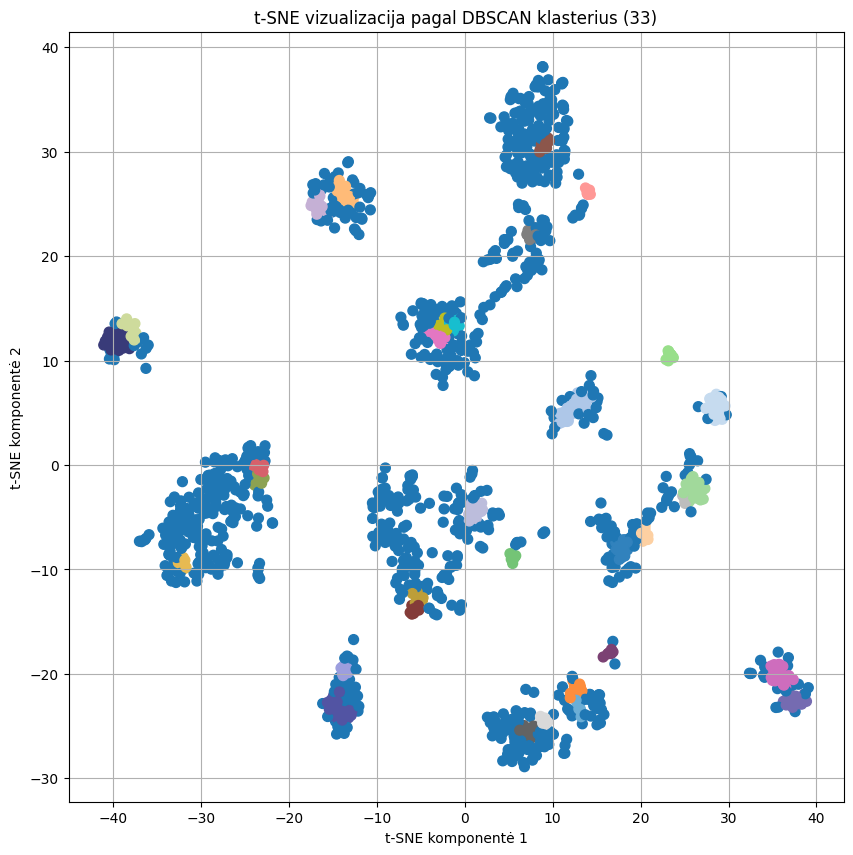

In [ ]:
plt.figure(figsize=(10, 10))
colors = plt.cm.get_cmap('tab20c', 76)
cmap = ListedColormap(colors)

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels,
    cmap=cmap,
    s=50
)
plt.title(f"t-SNE vizualizacija pagal DBSCAN klasterius ({n_clusters})")
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.grid(True)
plt.show()
